<a href="https://colab.research.google.com/github/hjchoi00/AI_lab/blob/main/Transfer_Learning_for_Computer_Vision_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 설정

In [23]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

압축 풀기

In [24]:
import os
import zipfile

# 압축파일 경로 지정
zip_path = "/content/sample_computer_vision.zip"

# 압축 풀 경로
extract_path = "/content/data"

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("압축 해제 완료:", extract_path)
print("폴더 내 파일 목록:", os.listdir(extract_path))


압축 해제 완료: /content/data
폴더 내 파일 목록: ['.ipynb_checkpoints', 'sample_computer_vision']


In [25]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/sample_computer_vision'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


# 1. Visualize a few images / 데이터셋 시각화

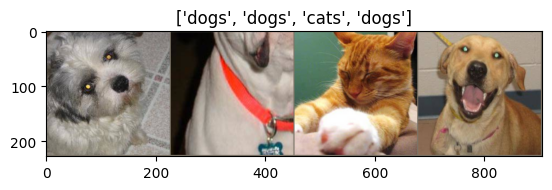

In [32]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model

In [33]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

## Finetuning the ConvNet

In [29]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 2. Train and evaluate / 학습 로그 및 정확도 출력

In [34]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5183 Acc: 0.8004
val Loss: 0.1564 Acc: 0.9300

Epoch 1/24
----------
train Loss: 0.5182 Acc: 0.7984
val Loss: 0.2018 Acc: 0.9300

Epoch 2/24
----------
train Loss: 0.4816 Acc: 0.8054
val Loss: 0.1481 Acc: 0.9550

Epoch 3/24
----------
train Loss: 0.4507 Acc: 0.8174
val Loss: 0.1753 Acc: 0.9350

Epoch 4/24
----------
train Loss: 0.4477 Acc: 0.8383
val Loss: 0.4873 Acc: 0.7950

Epoch 5/24
----------
train Loss: 0.4670 Acc: 0.8074
val Loss: 0.1149 Acc: 0.9700

Epoch 6/24
----------
train Loss: 0.2901 Acc: 0.8752
val Loss: 0.0995 Acc: 0.9700

Epoch 7/24
----------
train Loss: 0.2922 Acc: 0.8663
val Loss: 0.0921 Acc: 0.9700

Epoch 8/24
----------
train Loss: 0.2890 Acc: 0.8832
val Loss: 0.1180 Acc: 0.9550

Epoch 9/24
----------
train Loss: 0.2252 Acc: 0.9052
val Loss: 0.0989 Acc: 0.9700

Epoch 10/24
----------
train Loss: 0.2533 Acc: 0.8892
val Loss: 0.1049 Acc: 0.9650

Epoch 11/24
----------
train Loss: 0.2452 Acc: 0.9012
val Loss: 0.0955 Acc: 0.9750

Ep

# 3. 예측 결과 시각화

In [44]:
def visualize_model(model, num_images=6): # num_images에 모델 예측 시각화 갯수 지정
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

<Figure size 640x480 with 0 Axes>

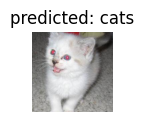

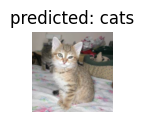

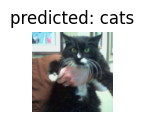

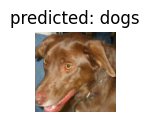

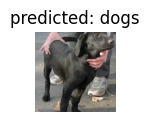

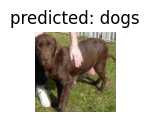

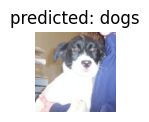

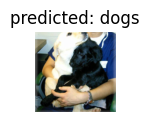

In [45]:
visualize_model(model_ft, 8)

## ConvNet as fixed feature extractor

In [13]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

## Train and evaluate

In [14]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5012 Acc: 0.7655
val Loss: 0.1692 Acc: 0.9400

Epoch 1/24
----------
train Loss: 0.4662 Acc: 0.7864
val Loss: 0.1605 Acc: 0.9600

Epoch 2/24
----------
train Loss: 0.3964 Acc: 0.8273
val Loss: 0.2372 Acc: 0.9200

Epoch 3/24
----------
train Loss: 0.5308 Acc: 0.7994
val Loss: 0.1585 Acc: 0.9550

Epoch 4/24
----------
train Loss: 0.5208 Acc: 0.8014
val Loss: 0.1605 Acc: 0.9450

Epoch 5/24
----------
train Loss: 0.5281 Acc: 0.8004
val Loss: 0.1312 Acc: 0.9700

Epoch 6/24
----------
train Loss: 0.5320 Acc: 0.8144
val Loss: 0.1136 Acc: 0.9750

Epoch 7/24
----------
train Loss: 0.3768 Acc: 0.8583
val Loss: 0.1253 Acc: 0.9550

Epoch 8/24
----------
train Loss: 0.3025 Acc: 0.8643
val Loss: 0.1066 Acc: 0.9700

Epoch 9/24
----------
train Loss: 0.3155 Acc: 0.8643
val Loss: 0.1193 Acc: 0.9550

Epoch 10/24
----------
train Loss: 0.3162 Acc: 0.8683
val Loss: 0.0951 Acc: 0.9700

Epoch 11/24
----------
train Loss: 0.3521 Acc: 0.8573
val Loss: 0.0986 Acc: 0.9750

Ep

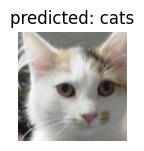

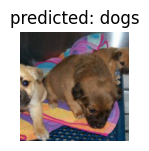

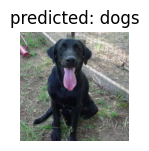

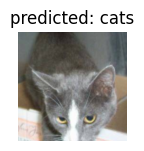

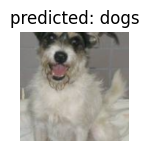

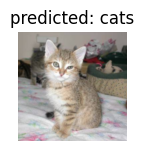

In [37]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images / 단일 이미지 예측

In [16]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

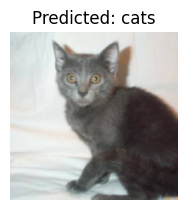

In [47]:
visualize_model_predictions(
    model_conv,
    img_path='data/sample_computer_vision/val/cats/cat.4014.jpg'
)

plt.ioff()
plt.show()